# Urban Air Quality Analysis and Pollution Level Prediction Using Machine Learning

## Project Overview

This project analyzes real-time air quality data collected from monitoring
stations across India. The analysis focuses on understanding pollutant
concentrations across different cities, states, and monitoring stations.

The project includes data cleaning, exploratory data analysis, visualization,
and machine learning-based prediction of pollutant concentration.
#
# Dataset:
# CPCB / Open Government Data Platform India

## Objectives

1. Clean and preprocess the air quality dataset.
2. Analyze pollutant concentrations across locations.
3. Identify patterns and differences in air pollution levels.
4. Visualize important air quality characteristics.
5. Develop a machine learning model for pollutant-level prediction.
6. Evaluate the performance of the prediction model.
7. Generate data-driven environmental insights and recommendations.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn


# 1. IMPORT LIBRARIES



In [115]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")




Libraries imported successfully.



# 2. LOAD DATASET




In [116]:


from google.colab import files

uploaded = files.upload()

df = pd.read_csv("3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv")

Saving 3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv to 3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69 (5).csv


In [117]:
print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())



Dataset loaded successfully.
Dataset shape: (3444, 11)

First 5 rows:


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",21-09-2026 11:00:00,26.446912,91.439057,CO,21.0,22.0,22.0
1,India,Assam,Nalbari,"Bata Chowk, Nalbari - PCBA",21-09-2026 11:00:00,26.446912,91.439057,OZONE,19.0,19.0,19.0
2,India,Assam,Silchar,"Tarapur, Silchar - PCBA",21-09-2026 11:00:00,24.828270,92.795250,PM2.5,28.0,34.0,30.0
3,India,Assam,Silchar,"Tarapur, Silchar - PCBA",21-09-2026 11:00:00,24.828270,92.795250,PM10,50.0,71.0,59.0
4,India,Assam,Silchar,"Tarapur, Silchar - PCBA",21-09-2026 11:00:00,24.828270,92.795250,SO2,3.0,5.0,4.0


# 3. BASIC DATASET INFORMATION

In [118]:

print("=" * 70)
print("BASIC DATASET INFORMATION")
print("=" * 70)

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDataset information:")
df.info()


BASIC DATASET INFORMATION

Shape:
(3444, 11)

Columns:
['country', 'state', 'city', 'station', 'last_update', 'latitude', 'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max', 'pollutant_avg']

Data types:
country           object
state             object
city              object
station           object
last_update       object
latitude         float64
longitude        float64
pollutant_id      object
pollutant_min    float64
pollutant_max    float64
pollutant_avg    float64
dtype: object

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3444 entries, 0 to 3443
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3444 non-null   object 
 1   state          3444 non-null   object 
 2   city           3444 non-null   object 
 3   station        3444 non-null   object 
 4   last_update    3444 non-null   object 
 5   latitude       3444 non-null   float64
 6   longitude 

# 4. CHECK UNIQUE VALUES

In [119]:
print("\n" + "=" * 70)
print("UNIQUE VALUES")
print("=" * 70)

print("\nNumber of states:", df['state'].nunique())
print("Number of cities:", df['city'].nunique())
print("Number of stations:", df['station'].nunique())

print("\nPollutants:")
print(sorted(df['pollutant_id'].dropna().unique()))

print("\nNumber of records for each pollutant:")
print(df['pollutant_id'].value_counts())



UNIQUE VALUES

Number of states: 31
Number of cities: 258
Number of stations: 492

Pollutants:
['CO', 'NH3', 'NO2', 'OZONE', 'PM10', 'PM2.5', 'SO2']

Number of records for each pollutant:
pollutant_id
CO       492
OZONE    492
PM2.5    492
PM10     492
SO2      492
NH3      492
NO2      492
Name: count, dtype: int64



# 5. CHECK MISSING VALUES



In [120]:
print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing_values = df.isnull().sum()

print(missing_values)

print("\nTotal missing values:",
      df.isnull().sum().sum())



MISSING VALUES
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    329
pollutant_max    329
pollutant_avg    329
dtype: int64

Total missing values: 987



# 6. CHECK DUPLICATE ROWS


In [121]:

print("\n" + "=" * 70)
print("DUPLICATE ROWS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)




DUPLICATE ROWS
Number of duplicate rows: 0




# 7. CHECK NEGATIVE POLLUTANT VALUES


In [122]:

print("\n" + "=" * 70)
print("NEGATIVE VALUE CHECK")
print("=" * 70)

numeric_pollutant_columns = [
    'pollutant_min',
    'pollutant_max',
    'pollutant_avg'
]

for column in numeric_pollutant_columns:

    negative_count = (
        df[column].dropna() < 0
    ).sum()

    print(
        f"{column}: {negative_count} negative values"
    )




NEGATIVE VALUE CHECK
pollutant_min: 0 negative values
pollutant_max: 0 negative values
pollutant_avg: 0 negative values




# 8. CONVERT DATE/TIME COLUMN


In [123]:

print("\n" + "=" * 70)
print("DATE/TIME CONVERSION")
print("=" * 70)

df['last_update'] = pd.to_datetime(
    df['last_update'],
    format='%d-%m-%Y %H:%M:%S',
    errors='coerce'
)

print("Data type after conversion:")
print(df['last_update'].dtype)

print("Invalid date values:",
      df['last_update'].isnull().sum())




DATE/TIME CONVERSION
Data type after conversion:
datetime64[ns]
Invalid date values: 0



# 9. REMOVE DUPLICATES

In [124]:
before_duplicates = len(df)

df = df.drop_duplicates().copy()

after_duplicates = len(df)

print("\nRows before removing duplicates:",
      before_duplicates)

print("Rows after removing duplicates:",
      after_duplicates)

print("Duplicates removed:",
      before_duplicates - after_duplicates)




Rows before removing duplicates: 3444
Rows after removing duplicates: 3444
Duplicates removed: 0


# 10. REMOVE ROWS WITHOUT POLLUTANT AVERAGE

In [125]:


print("\n" + "=" * 70)
print("REMOVING MISSING POLLUTANT MEASUREMENTS")
print("=" * 70)

missing_before = df['pollutant_avg'].isnull().sum()

df_clean = df.dropna(
    subset=['pollutant_avg']
).copy()

missing_after = df_clean['pollutant_avg'].isnull().sum()

print("Rows with missing pollutant_avg before cleaning:",
      missing_before)

print("Rows after cleaning:",
      len(df_clean))

print("Missing pollutant_avg after cleaning:",
      missing_after)



REMOVING MISSING POLLUTANT MEASUREMENTS
Rows with missing pollutant_avg before cleaning: 329
Rows after cleaning: 3115
Missing pollutant_avg after cleaning: 0



# 11. FINAL CLEAN DATASET CHECK


In [126]:

print("\n" + "=" * 70)
print("CLEAN DATASET CHECK")
print("=" * 70)

print("Original dataset shape:", df.shape)
print("Clean dataset shape:", df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate rows:",
      df_clean.duplicated().sum())




CLEAN DATASET CHECK
Original dataset shape: (3444, 11)
Clean dataset shape: (3115, 11)

Missing values:
country          0
state            0
city             0
station          0
last_update      0
latitude         0
longitude        0
pollutant_id     0
pollutant_min    0
pollutant_max    0
pollutant_avg    0
dtype: int64

Duplicate rows: 0



# 12. DESCRIPTIVE STATISTICS


In [127]:


print("\n" + "=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)

display(
    df_clean[
        ['pollutant_min',
         'pollutant_max',
         'pollutant_avg']
    ].describe()
)




DESCRIPTIVE STATISTICS


,pollutant_min,pollutant_max,pollutant_avg
count,3115.000000,3115.000000,3115.000000
mean,22.276726,53.747352,34.518138
std,25.571700,65.646232,38.634279
min,0.000000,0.000000,0.000000
25%,5.000000,12.000000,9.000000
50%,14.000000,33.000000,22.000000
75%,30.000000,67.000000,45.000000
max,200.000000,500.000000,288.000000




# 13. POLLUTANT-WISE STATISTICS




In [128]:

print("\n" + "=" * 70)
print("POLLUTANT-WISE STATISTICS")
print("=" * 70)

pollutant_stats = (
    df_clean
    .groupby('pollutant_id')['pollutant_avg']
    .agg(
        count='count',
        mean='mean',
        median='median',
        minimum='min',
        maximum='max',
        std='std'
    )
    .sort_values('mean', ascending=False)
)

display(
    pollutant_stats.round(2)
)


POLLUTANT-WISE STATISTICS


,count,mean,median,minimum,maximum,std
pollutant_id,,,,,,
PM10,436,77.65,66.5,10.0,288.0,44.52
PM2.5,440,66.97,49.0,2.0,284.0,52.74
CO,471,34.66,30.0,2.0,196.0,23.20
NO2,454,22.52,18.0,0.0,163.0,17.85
OZONE,468,21.45,18.0,0.0,90.0,14.83
SO2,433,13.03,9.0,0.0,96.0,13.07
NH3,413,4.78,4.0,0.0,24.0,3.73




# 14. AVAILABLE MEASUREMENTS BY POLLUTANT


In [129]:

print("\n" + "=" * 70)
print("AVAILABLE MEASUREMENTS BY POLLUTANT")
print("=" * 70)

pollutant_counts = (
    df_clean['pollutant_id']
    .value_counts()
    .sort_values(ascending=False)
)

print(pollutant_counts)



AVAILABLE MEASUREMENTS BY POLLUTANT
pollutant_id
CO       471
OZONE    468
NO2      454
PM2.5    440
PM10     436
SO2      433
NH3      413
Name: count, dtype: int64


# 15. VISUALIZATION 1
# AVERAGE REPORTED VALUE BY POLLUTANT

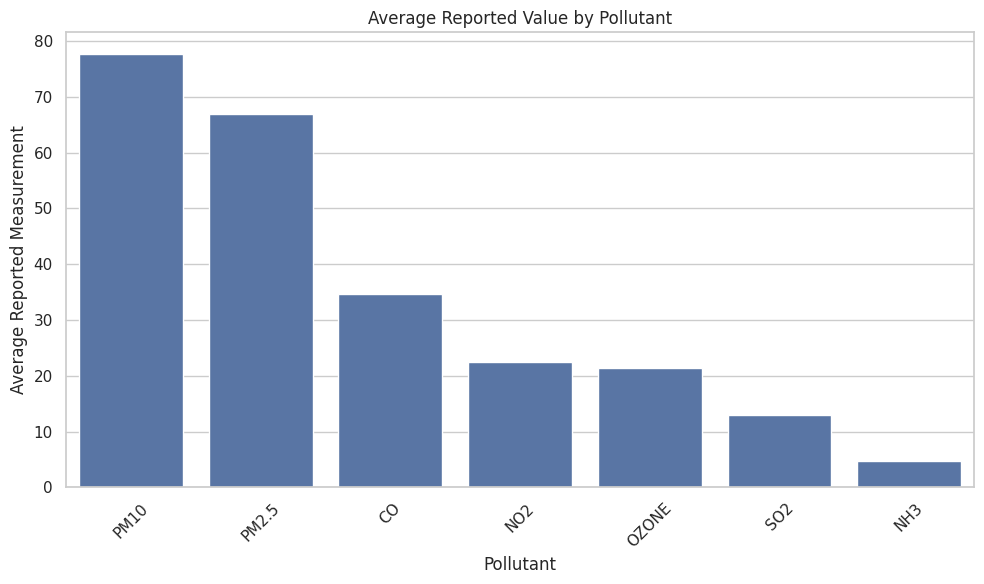

In [131]:


pollutant_mean = (
    df_clean
    .groupby('pollutant_id')['pollutant_avg']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=pollutant_mean.index,
    y=pollutant_mean.values
)

plt.title(
    'Average Reported Value by Pollutant'
)

plt.xlabel('Pollutant')
plt.ylabel('Average Reported Measurement')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



# 16. VISUALIZATION 2
# DISTRIBUTION OF POLLUTANT MEASUREMENTS

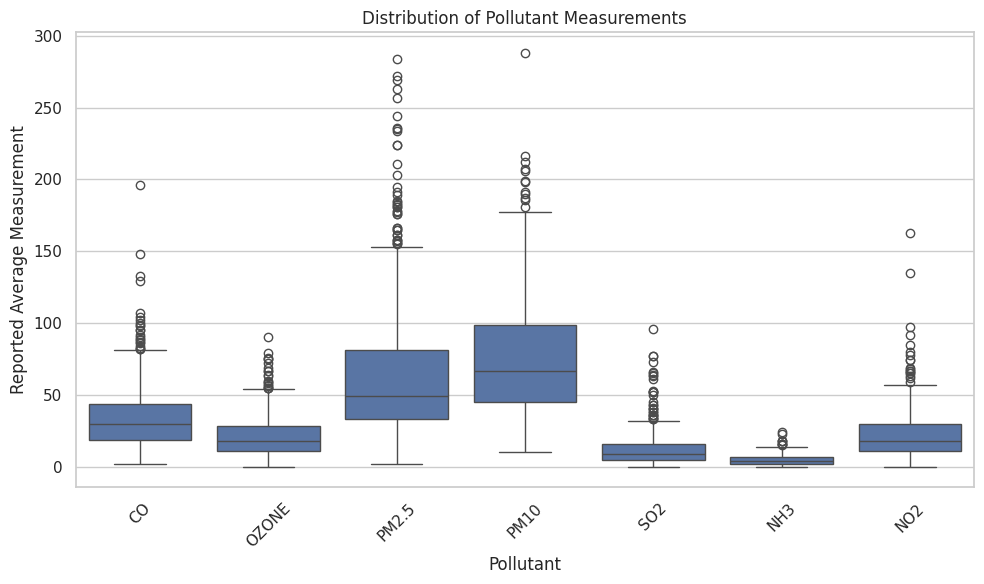

In [132]:

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x='pollutant_id',
    y='pollutant_avg'
)

plt.title(
    'Distribution of Pollutant Measurements'
)

plt.xlabel('Pollutant')
plt.ylabel('Reported Average Measurement')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# 17. STATE-WISE MEASUREMENT COUNT

In [133]:


state_counts = (
    df_clean
    .groupby('state')
    .size()
    .sort_values(ascending=False)
)

print("\nTop 10 states by available measurements:")
print(state_counts.head(10))




Top 10 states by available measurements:
state
Maharashtra       555
Uttar Pradesh     435
Rajasthan         319
Delhi             283
Haryana           183
Bihar             165
West Bengal       150
Madhya Pradesh    133
Gujarat           123
Karnataka         122
dtype: int64



# 18. VISUALIZATION 3
# TOP 10 STATES BY AVAILABLE MEASUREMENTS

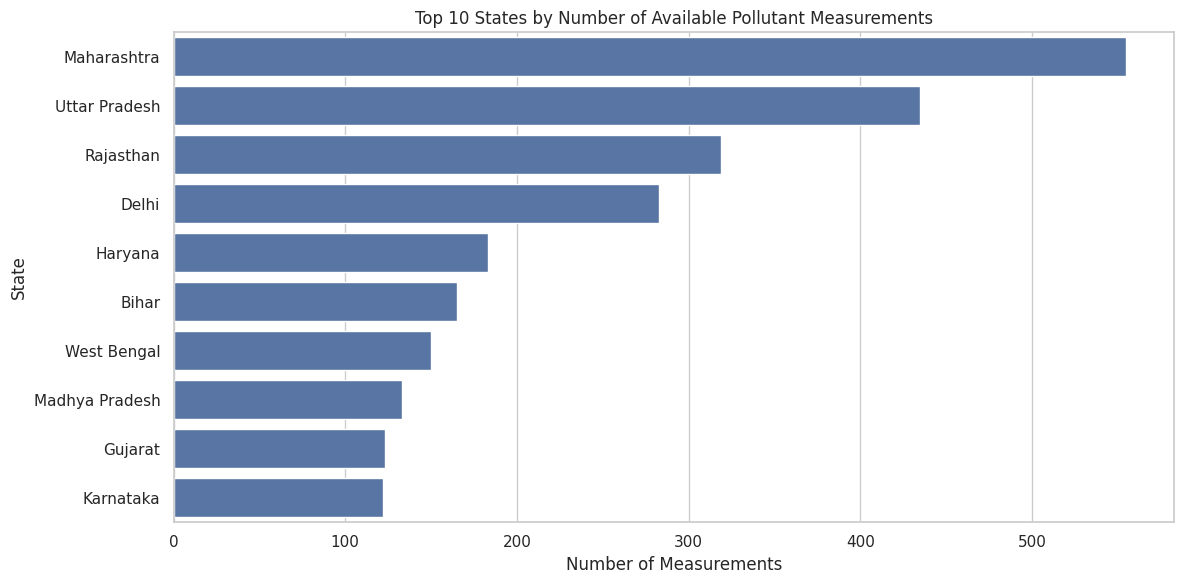

In [134]:

# ================================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    x=state_counts.head(10).values,
    y=state_counts.head(10).index
)

plt.title(
    'Top 10 States by Number of Available Pollutant Measurements'
)

plt.xlabel('Number of Measurements')
plt.ylabel('State')

plt.tight_layout()
plt.show()




# 19. FILTER PM2.5 DATA


In [135]:

pm25_data = df_clean[
    df_clean['pollutant_id'] == 'PM2.5'
].copy()

print("\nPM2.5 records:", len(pm25_data))



PM2.5 records: 440


# 20. PM2.5 BY STATE

In [136]:
pm25_state = (
    pm25_data
    .groupby('state')['pollutant_avg']
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 states by average PM2.5:")
print(pm25_state.head(10).round(2))



Top 10 states by average PM2.5:
state
Delhi               145.24
Meghalaya           144.00
Haryana             119.19
Uttar Pradesh        96.07
Gujarat              82.67
Himachal Pradesh     71.00
Punjab               69.50
Rajasthan            67.64
Andhra Pradesh       48.43
Telangana            47.83
Name: pollutant_avg, dtype: float64


# 21. VISUALIZATION 4
# TOP 10 STATES BY AVERAGE PM2.5


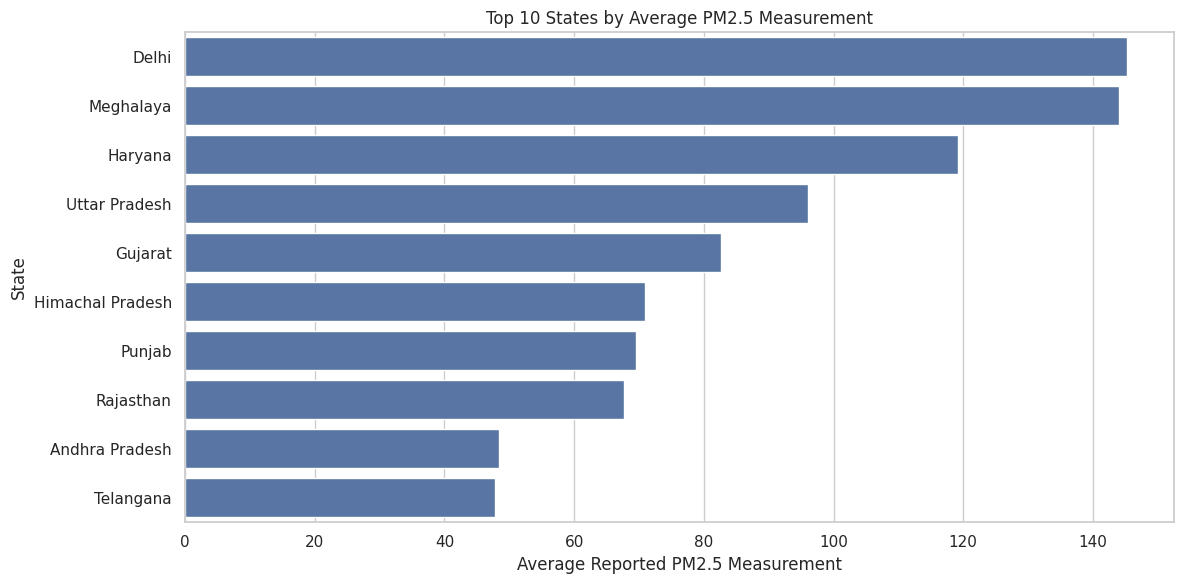

In [137]:

plt.figure(figsize=(12, 6))

sns.barplot(
    x=pm25_state.head(10).values,
    y=pm25_state.head(10).index
)

plt.title(
    'Top 10 States by Average PM2.5 Measurement'
)

plt.xlabel(
    'Average Reported PM2.5 Measurement'
)

plt.ylabel('State')

plt.tight_layout()
plt.show()


# 22. PM2.5 BY CITY

In [138]:


pm25_city = (
    pm25_data
    .groupby('city')['pollutant_avg']
    .mean()
    .sort_values(ascending=False)
)

print("\nTop 10 cities by average PM2.5:")
print(pm25_city.head(10).round(2))



Top 10 cities by average PM2.5:
city
Manesar          272.00
Baraut           269.00
Khora            257.00
Greater Noida    240.00
Gurugram         214.00
Bahadurgarh      195.00
Khairthal        181.00
Jind             178.00
Yamuna Nagar     177.00
Noida            170.75
Name: pollutant_avg, dtype: float64


# 23. VISUALIZATION 5
# TOP 10 CITIES BY AVERAGE PM2.5

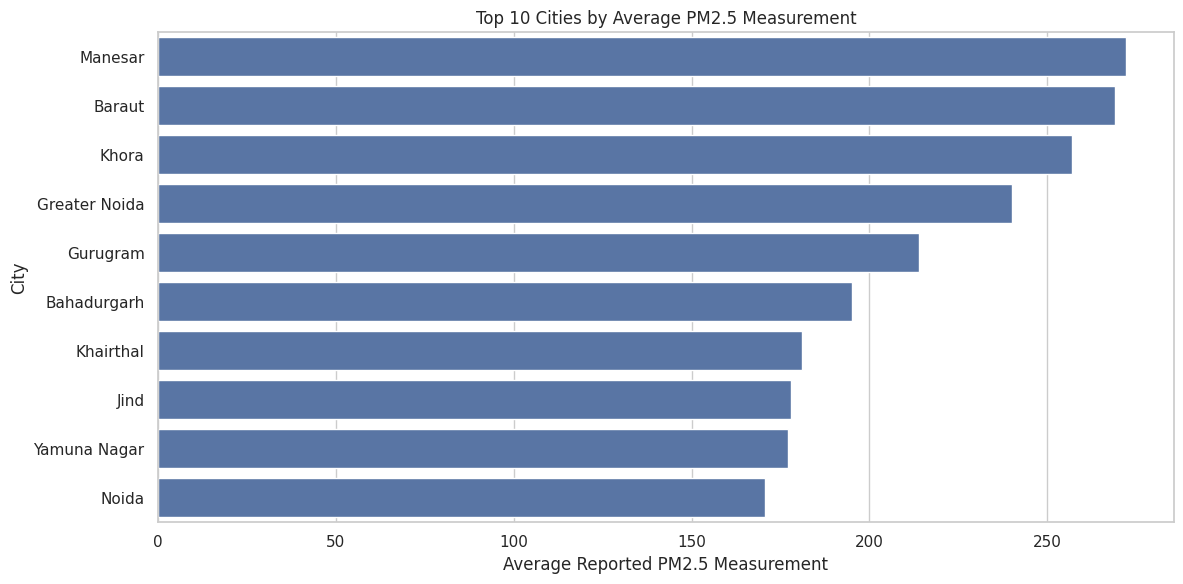

In [139]:


plt.figure(figsize=(12, 6))

sns.barplot(
    x=pm25_city.head(10).values,
    y=pm25_city.head(10).index
)

plt.title(
    'Top 10 Cities by Average PM2.5 Measurement'
)

plt.xlabel(
    'Average Reported PM2.5 Measurement'
)

plt.ylabel('City')

plt.tight_layout()
plt.show()



# 24. PM2.5 VS PM10

In [140]:


pm_comparison = (
    df_clean[
        df_clean['pollutant_id'].isin(
            ['PM2.5', 'PM10']
        )
    ]
    .groupby('pollutant_id')['pollutant_avg']
    .mean()
)

print("\nAverage PM2.5 and PM10:")
print(pm_comparison.round(2))



Average PM2.5 and PM10:
pollutant_id
PM10     77.65
PM2.5    66.97
Name: pollutant_avg, dtype: float64


# 25. VISUALIZATION 6
# PM2.5 VS PM10

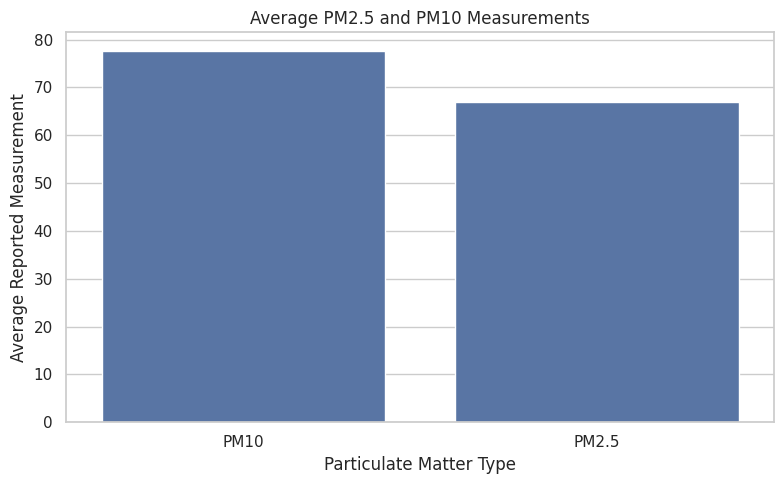

In [141]:

plt.figure(figsize=(8, 5))

sns.barplot(
    x=pm_comparison.index,
    y=pm_comparison.values
)

plt.title(
    'Average PM2.5 and PM10 Measurements'
)

plt.xlabel('Particulate Matter Type')
plt.ylabel('Average Reported Measurement')

plt.tight_layout()
plt.show()



# 26. CREATING STATION-POLLUTANT TABLE


In [142]:



station_pollutants = (
    df_clean
    .pivot_table(
        index=[
            'country',
            'state',
            'city',
            'station',
            'latitude',
            'longitude'
        ],
        columns='pollutant_id',
        values='pollutant_avg',
        aggfunc='mean'
    )
    .reset_index()
)

print("\nStation-level dataset:")
print("Shape:", station_pollutants.shape)

display(station_pollutants.head())



Station-level dataset:
Shape: (492, 13)


pollutant_id,country,state,city,station,latitude,longitude,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
0,India,Andhra Pradesh,Amaravati,"Secretariat, Amaravati - APPCB",16.515083,80.518167,21.0,4.0,27.0,19.0,73.0,49.0,6.0
1,India,Andhra Pradesh,Anantapur,"Gulzarpet, Anantapur - APPCB",14.675886,77.593027,27.0,5.0,17.0,29.0,71.0,66.0,18.0
2,India,Andhra Pradesh,Chittoor,"Gangineni Cheruvu, Chittoor - APPCB",13.204880,79.097889,15.0,8.0,34.0,27.0,71.0,70.0,18.0
3,India,Andhra Pradesh,Eluru,"District Court, Eluru - APPCB",16.711754,81.092095,21.0,3.0,1.0,9.0,44.0,48.0,11.0
4,India,Andhra Pradesh,Guntur,"Rajendra Nagar North, Guntur - APPCB",16.316553,80.413302,22.0,7.0,35.0,17.0,63.0,55.0,19.0


# 27. CORRELATION MATRIX

In [143]:




pollutant_columns = [
    'CO',
    'NH3',
    'NO2',
    'OZONE',
    'PM10',
    'PM2.5',
    'SO2'
]

available_pollutant_columns = [
    column
    for column in pollutant_columns
    if column in station_pollutants.columns
]

correlation = (
    station_pollutants[
        available_pollutant_columns
    ].corr()
)

print("\nPollutant correlation matrix:")
display(correlation.round(2))



Pollutant correlation matrix:


pollutant_id,CO,NH3,NO2,OZONE,PM10,PM2.5,SO2
pollutant_id,,,,,,,
CO,1.00,0.09,0.24,0.08,0.30,0.27,0.11
NH3,0.09,1.00,0.36,0.12,0.35,0.32,-0.03
NO2,0.24,0.36,1.00,0.17,0.37,0.33,0.05
OZONE,0.08,0.12,0.17,1.00,0.17,0.11,-0.04
PM10,0.30,0.35,0.37,0.17,1.00,0.85,0.12
PM2.5,0.27,0.32,0.33,0.11,0.85,1.00,0.10
SO2,0.11,-0.03,0.05,-0.04,0.12,0.10,1.00


# 28. VISUALIZATION 7
# CORRELATION HEATMAP

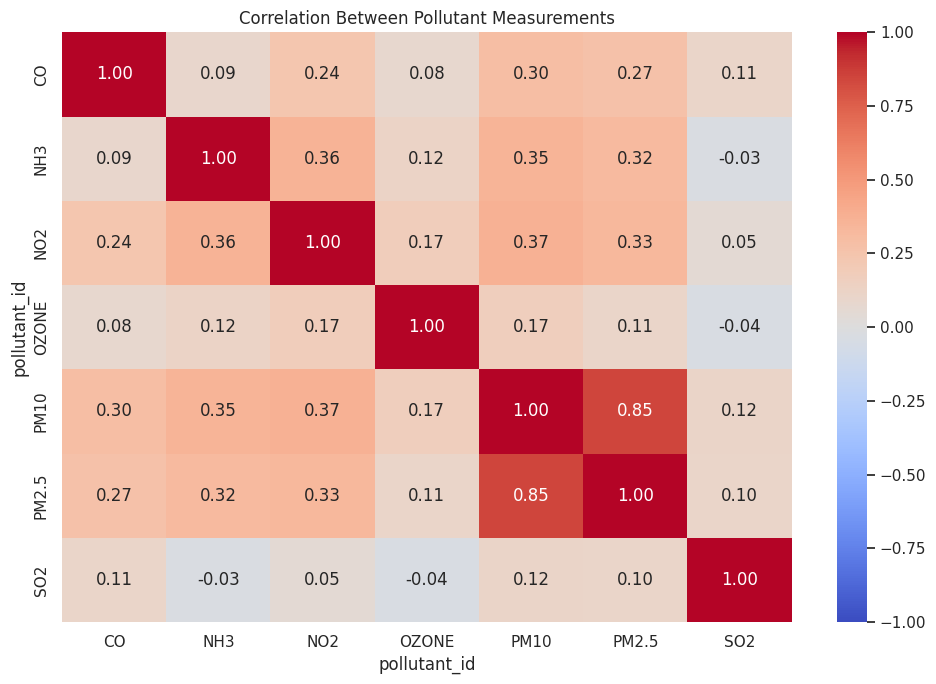

In [144]:


plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1
)

plt.title(
    'Correlation Between Pollutant Measurements'
)

plt.tight_layout()
plt.show()



# 29. FIND STRONGEST CORRELATIONS

In [145]:

corr_pairs = (
    correlation
    .where(
        np.triu(
            np.ones(correlation.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .sort_values(
        key=lambda x: abs(x),
        ascending=False
    )
)

print("\nStrongest pollutant relationships:")
print(corr_pairs.head(10).round(2))



Strongest pollutant relationships:
pollutant_id  pollutant_id
PM10          PM2.5           0.85
NO2           PM10            0.37
NH3           NO2             0.36
              PM10            0.35
NO2           PM2.5           0.33
NH3           PM2.5           0.32
CO            PM10            0.30
              PM2.5           0.27
              NO2             0.24
NO2           OZONE           0.17
dtype: float64


# 30. STATION COMPLETENESS

In [146]:



station_completeness = (
    df_clean
    .groupby('station')['pollutant_id']
    .count()
)

complete_station_count = (
    station_completeness == 7
).sum()

total_station_count = (
    station_completeness.shape[0]
)

print("\n" + "=" * 70)
print("STATION COMPLETENESS")
print("=" * 70)

print(
    "Stations with all 7 pollutants:",
    complete_station_count
)

print(
    "Total stations:",
    total_station_count
)

print(
    "Percentage complete:",
    round(
        complete_station_count /
        total_station_count * 100,
        2
    ),
    "%"
)



STATION COMPLETENESS
Stations with all 7 pollutants: 355
Total stations: 492
Percentage complete: 72.15 %


# 31. CREATE ML DATASET

In [147]:


ml_features = [
    'PM10',
    'NO2',
    'SO2',
    'CO',
    'OZONE',
    'NH3',
    'latitude',
    'longitude'
]

target = 'PM2.5'

ml_data = station_pollutants[
    ml_features + [target]
].dropna().copy()

print("\n" + "=" * 70)
print("MACHINE LEARNING DATASET")
print("=" * 70)

print("ML dataset shape:", ml_data.shape)

print("\nMissing values:")
print(ml_data.isnull().sum())

display(ml_data.head())




MACHINE LEARNING DATASET
ML dataset shape: (355, 9)

Missing values:
pollutant_id
PM10         0
NO2          0
SO2          0
CO           0
OZONE        0
NH3          0
latitude     0
longitude    0
PM2.5        0
dtype: int64


pollutant_id,PM10,NO2,SO2,CO,OZONE,NH3,latitude,longitude,PM2.5
0,73.0,27.0,6.0,21.0,19.0,4.0,16.515083,80.518167,49.0
1,71.0,17.0,18.0,27.0,29.0,5.0,14.675886,77.593027,66.0
2,71.0,34.0,18.0,15.0,27.0,8.0,13.204880,79.097889,70.0
3,44.0,1.0,11.0,21.0,9.0,3.0,16.711754,81.092095,48.0
4,63.0,35.0,19.0,22.0,17.0,7.0,16.316553,80.413302,55.0


# 32. CHECK WHETHER ENOUGH DATA EXISTS

In [148]:


if len(ml_data) < 20:

    raise ValueError(
        "Not enough complete station records for machine learning."
    )

print(
    "\nNumber of complete records available for ML:",
    len(ml_data)
)



Number of complete records available for ML: 355


In [149]:


# ================================================================
# 33. DEFINE X AND y
# ================================================================

X = ml_data[ml_features]

y = ml_data[target]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print(target)



Features:
['PM10', 'NO2', 'SO2', 'CO', 'OZONE', 'NH3', 'latitude', 'longitude']

Target:
PM2.5



# 34. TRAIN-TEST SPLIT


In [150]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))




Training records: 284
Testing records: 71




# 35. FEATURE SCALING

#
# Scaling is useful for Linear Regression.
#
# Tree-based models do not require scaling, but using the same
# train/test features makes the comparison easier.


In [151]:


scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)


# 36. MODEL 1 - LINEAR REGRESSION

In [152]:


linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_model.predict(
    X_test_scaled
)


# 37. MODEL 2 - DECISION TREE REGRESSOR

In [154]:


tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(
    X_test
)


# 38. MODEL 3 - RANDOM FOREST REGRESSOR

In [155]:


forest_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

forest_model.fit(
    X_train,
    y_train
)

forest_predictions = forest_model.predict(
    X_test
)


# 39. MODEL EVALUATION FUNCTION

In [156]:

def evaluate_model(
    model_name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }


# 40. EVALUATE ALL MODELS

In [157]:




results = []

results.append(
    evaluate_model(
        'Linear Regression',
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        'Decision Tree',
        y_test,
        tree_predictions
    )
)

results.append(
    evaluate_model(
        'Random Forest',
        y_test,
        forest_predictions
    )
)

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

display(
    results_df.round(3)
)



MODEL PERFORMANCE COMPARISON


,Model,MAE,RMSE,R2 Score
0,Linear Regression,20.223,29.165,0.751
1,Decision Tree,24.125,33.764,0.666
2,Random Forest,19.303,27.167,0.784


# 41. MODEL PERFORMANCE VISUALIZATION

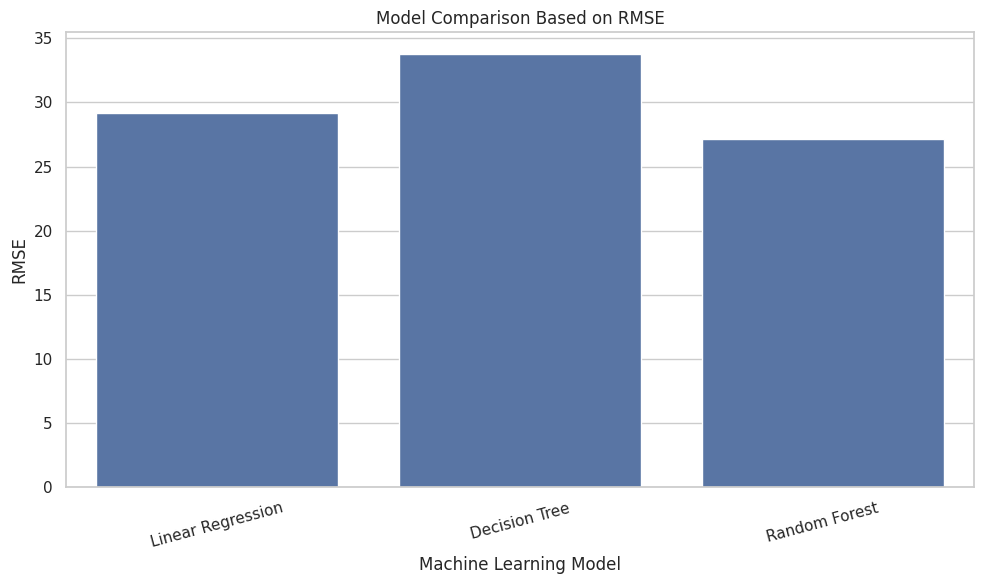

In [158]:


plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE'
)

plt.title(
    'Model Comparison Based on RMSE'
)

plt.xlabel('Machine Learning Model')
plt.ylabel('RMSE')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


# 42. R2 SCORE COMPARISON

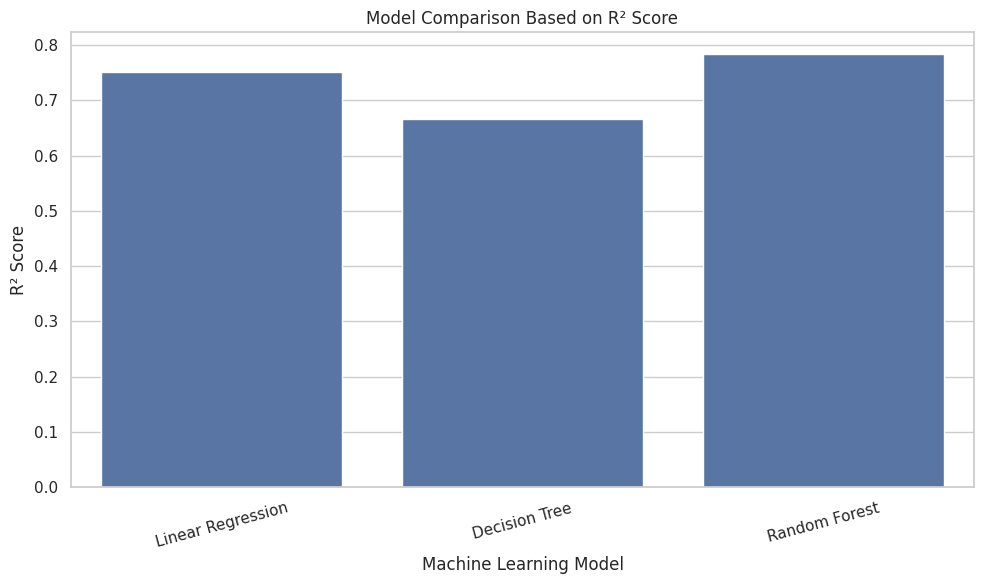

In [159]:

plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title(
    'Model Comparison Based on R² Score'
)

plt.xlabel('Machine Learning Model')
plt.ylabel('R² Score')

plt.xticks(rotation=15)

plt.tight_layout()
plt.show()


# 43. SELECT MODEL FOR PREDICTION

In [160]:


best_model_name = (
    results_df
    .sort_values(
        'R2 Score',
        ascending=False
    )
    .iloc[0]['Model']
)

print(
    "\nModel with highest R² score:",
    best_model_name
)



Model with highest R² score: Random Forest


# 44. SELECT CORRESPONDING PREDICTIONS

In [161]:

prediction_dictionary = {
    'Linear Regression': linear_predictions,
    'Decision Tree': tree_predictions,
    'Random Forest': forest_predictions
}

selected_predictions = prediction_dictionary[
    best_model_name
]




# 45. ACTUAL VS PREDICTED PM2.5

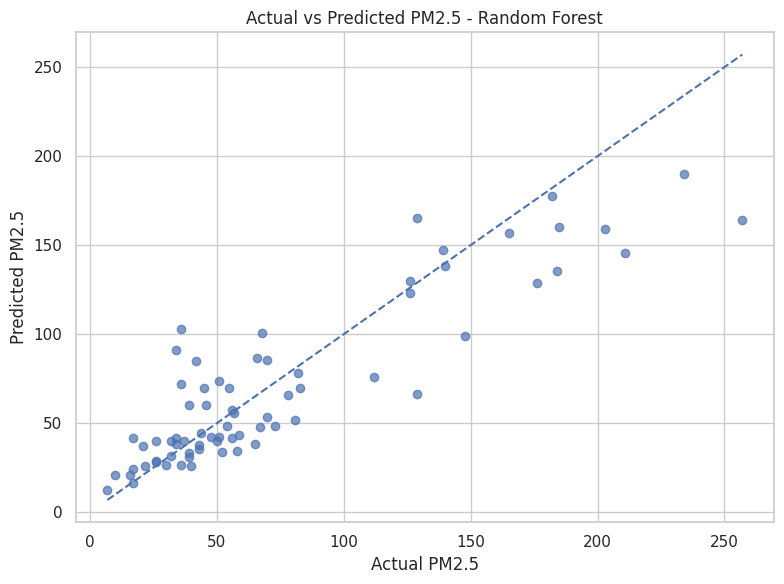

# 46. RESIDUAL ANALYSIS

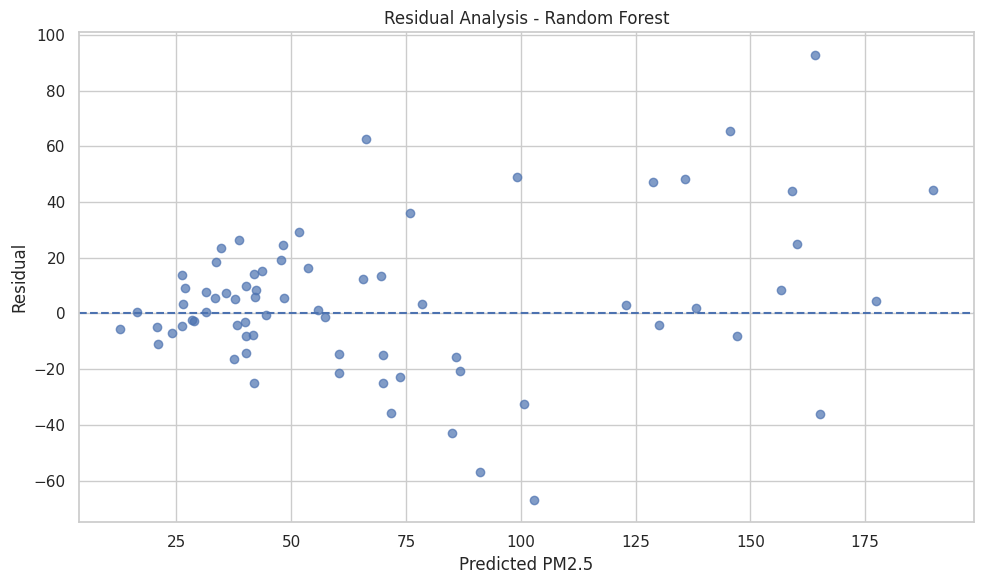

In [168]:

residuals = (
    y_test.values -
    selected_predictions
)

plt.figure(figsize=(10, 6))

plt.scatter(
    selected_predictions,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.title(
    f'Residual Analysis - {best_model_name}'
)

plt.xlabel('Predicted PM2.5')
plt.ylabel('Residual')

plt.tight_layout()
plt.show()



# ================================================================
# 47. FEATURE IMPORTANCE


FEATURE IMPORTANCE
PM10         0.7475
latitude     0.0781
longitude    0.0411
CO           0.0329
OZONE        0.0294
SO2          0.0291
NO2          0.0211
NH3          0.0207
dtype: float64


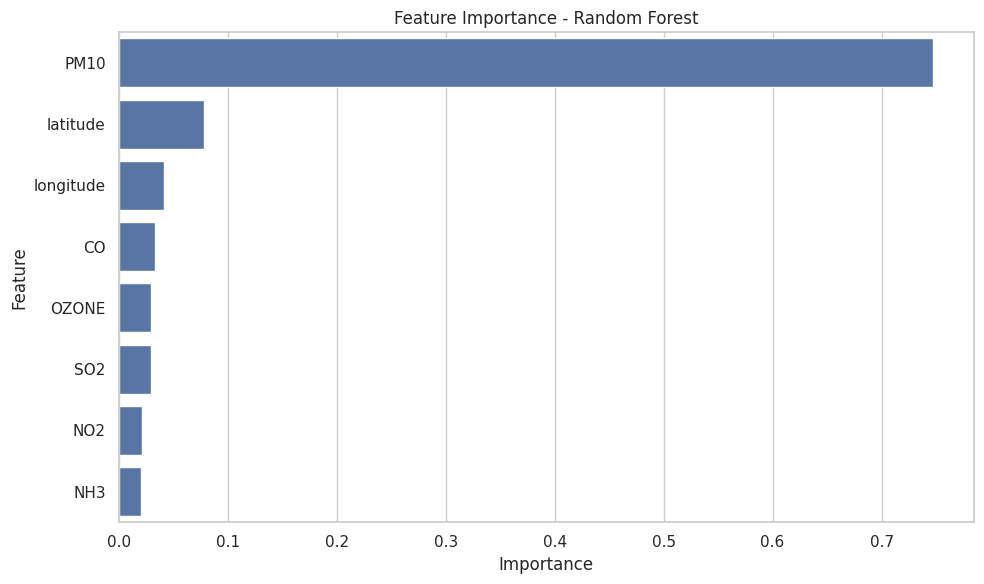

In [169]:


if best_model_name == 'Random Forest':

    feature_importance = pd.Series(
        forest_model.feature_importances_,
        index=ml_features
    )

elif best_model_name == 'Decision Tree':

    feature_importance = pd.Series(
        tree_model.feature_importances_,
        index=ml_features
    )

else:

    feature_importance = None


if feature_importance is not None:

    feature_importance = (
        feature_importance
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 70)
    print("FEATURE IMPORTANCE")
    print("=" * 70)

    print(
        feature_importance.round(4)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=feature_importance.values,
        y=feature_importance.index
    )

    plt.title(
        f'Feature Importance - {best_model_name}'
    )

    plt.xlabel('Importance')
    plt.ylabel('Feature')

    plt.tight_layout()
    plt.show()


# 48. SAMPLE PM2.5 PREDICTION

In [170]:


print("\n" + "=" * 70)
print("SAMPLE PM2.5 PREDICTION")
print("=" * 70)

sample = X_test.iloc[[0]]

actual_value = y_test.iloc[0]

if best_model_name == 'Linear Regression':

    sample_scaled = scaler.transform(sample)

    predicted_value = (
        linear_model.predict(sample_scaled)[0]
    )

elif best_model_name == 'Decision Tree':

    predicted_value = (
        tree_model.predict(sample)[0]
    )

else:

    predicted_value = (
        forest_model.predict(sample)[0]
    )

print("\nInput pollutant/environmental features:")
display(sample)

print(
    f"\nActual PM2.5: {actual_value:.2f}"
)

print(
    f"Predicted PM2.5: {predicted_value:.2f}"
)



SAMPLE PM2.5 PREDICTION

Input pollutant/environmental features:


pollutant_id,PM10,NO2,SO2,CO,OZONE,NH3,latitude,longitude
323,61.0,13.0,61.0,9.0,17.0,4.0,20.936071,85.170702



Actual PM2.5: 54.00
Predicted PM2.5: 48.41


# 49. AUTOMATIC PROJECT FINDINGS

In [171]:



print("\n" + "=" * 70)
print("PROJECT FINDINGS")
print("=" * 70)

highest_pollutant = pollutant_mean.idxmax()
highest_pollutant_value = pollutant_mean.max()

lowest_pollutant = pollutant_mean.idxmin()
lowest_pollutant_value = pollutant_mean.min()

print(
    f"\n1. Among the pollutant categories, "
    f"{highest_pollutant} has the highest average reported value "
    f"({highest_pollutant_value:.2f}) in this dataset snapshot."
)

print(
    f"\n2. {lowest_pollutant} has the lowest average reported value "
    f"({lowest_pollutant_value:.2f}) among the pollutant categories."
)

print(
    f"\n3. The highest state-level average PM2.5 measurement "
    f"in the analyzed snapshot is observed for "
    f"{pm25_state.idxmax()} "
    f"({pm25_state.max():.2f})."
)

print(
    f"\n4. The highest city-level average PM2.5 measurement "
    f"in the analyzed snapshot is observed for "
    f"{pm25_city.idxmax()} "
    f"({pm25_city.max():.2f})."
)

if len(corr_pairs) > 0:

    strongest_pair = corr_pairs.index[0]
    strongest_value = corr_pairs.iloc[0]

    print(
        f"\n5. The strongest pollutant relationship is between "
        f"{strongest_pair[0]} and {strongest_pair[1]}, "
        f"with correlation {strongest_value:.2f}."
    )

print(
    f"\n6. {complete_station_count} out of "
    f"{total_station_count} stations have complete "
    f"measurements for all seven pollutant categories."
)

print(
    f"\n7. The machine-learning dataset contains "
    f"{len(ml_data)} complete station-level observations."
)

print(
    f"\n8. Three regression models were compared: "
    f"Linear Regression, Decision Tree Regressor, "
    f"and Random Forest Regressor."
)

print(
    f"\n9. Based on the selected evaluation criterion, "
    f"{best_model_name} achieved the highest R² score "
    f"among the tested models."
)



PROJECT FINDINGS

1. Among the pollutant categories, PM10 has the highest average reported value (77.65) in this dataset snapshot.

2. NH3 has the lowest average reported value (4.78) among the pollutant categories.

3. The highest state-level average PM2.5 measurement in the analyzed snapshot is observed for Delhi (145.24).

4. The highest city-level average PM2.5 measurement in the analyzed snapshot is observed for Manesar (272.00).

5. The strongest pollutant relationship is between PM10 and PM2.5, with correlation 0.85.

6. 355 out of 492 stations have complete measurements for all seven pollutant categories.

7. The machine-learning dataset contains 355 complete station-level observations.

8. Three regression models were compared: Linear Regression, Decision Tree Regressor, and Random Forest Regressor.

9. Based on the selected evaluation criterion, Random Forest achieved the highest R² score among the tested models.
